# Worksheet 02 - Image Classification Using Softmax Regression

This notebook solves the full worksheet with simple variable names and simple comments.


## 1) Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression


## 2) Softmax and prediction functions


In [2]:
def softmax(z):
    z = np.array(z)
    one_row = False

    if z.ndim == 1:
        z = z.reshape(1, -1)
        one_row = True

    # subtract max value for stable exp
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    if one_row:
        return probs[0]
    return probs


def predict_softmax(x, w, b):
    z = x @ w + b
    p = softmax(z)
    y_pred = np.argmax(p, axis=1)
    return y_pred


In [3]:
# test for softmax
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

# test for prediction
x_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
w_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(x_test, w_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)


Softmax function passed the test case!
Predicted class labels: [1 1 0]


## 3) Loss and cost functions


In [4]:
def loss_softmax(y_pred, y):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0 - eps)

    if y_pred.ndim == 1:
        return -np.sum(y * np.log(y_pred))

    return -np.mean(np.sum(y * np.log(y_pred), axis=1))


def cost_softmax(x, y, w, b):
    z = x @ w + b
    y_pred = softmax(z)
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0 - eps)

    n = x.shape[0]
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n


In [5]:
# test for loss
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                           [0.1, 0.85, 0.05],
                           [0.05, 0.1, 0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                             [0.1, 0.05, 0.85],
                             [0.85, 0.1, 0.05]])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)
assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, but got "
    f"{loss_correct:.4f} >= {loss_incorrect:.4f}"
)
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

# test for cost
x_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
w_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

x_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
w_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(x_correct, y_correct, w_correct, b_correct)
cost_incorrect = cost_softmax(x_incorrect, y_incorrect, w_incorrect, b_incorrect)
assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")


Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957
Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


## 4) Gradient and gradient descent


In [6]:
def compute_gradient_softmax(x, y, w, b):
    z = x @ w + b
    y_pred = softmax(z)

    n = x.shape[0]
    diff = y_pred - y

    grad_w = (x.T @ diff) / n
    grad_b = np.sum(diff, axis=0) / n
    return grad_w, grad_b


def gradient_descent_softmax(x, y, w, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_w, grad_b = compute_gradient_softmax(x, y, w, b)

        # update step
        w = w - alpha * grad_w
        b = b - alpha * grad_b

        c = cost_softmax(x, y, w, b)
        cost_history.append(c)

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"iter {i:4d} | cost {c:.6f}")

    return w, b, cost_history


In [7]:
# test for compute gradient
x_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
w_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_w, grad_b = compute_gradient_softmax(x_test, y_test, w_test, b_test)

z_test = np.dot(x_test, w_test) + b_test
y_pred_test = softmax(z_test)
grad_w_manual = np.dot(x_test.T, (y_pred_test - y_test)) / x_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / x_test.shape[0]

assert np.allclose(grad_w, grad_w_manual), (
    f"Test failed: Gradients w.r.t. W are not equal. Expected: {grad_w_manual} Got: {grad_w}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal. Expected: {grad_b_manual} Got: {grad_b}"
)
print("Gradient w.r.t. W:", grad_w)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")


Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


## 5) Question 1

**Is extracting pixel values enough for feature extraction?**

Pixel values are enough to build a basic model, and softmax regression can learn useful patterns from them.
But pixels alone ignore local shape details, so model performance can be limited.
For better accuracy, stronger features or stronger models (like CNNs) are usually better.


## 6) Load and prepare MNIST data


In [8]:
def plot_sample_images(x, y):
    plt.figure(figsize=(10, 4))
    classes = np.unique(y)

    for i, d in enumerate(classes):
        idx = np.where(y == d)[0][0]
        img = x[idx].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Digit: {d}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    x = df.iloc[:, 1:].values.astype(np.float64)

    # normalize pixel values to 0..1
    x = x / 255.0

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    plot_sample_images(x, y)
    return x_train, x_test, y_train, y_test


Using file: Dataset\mnist_train.csv


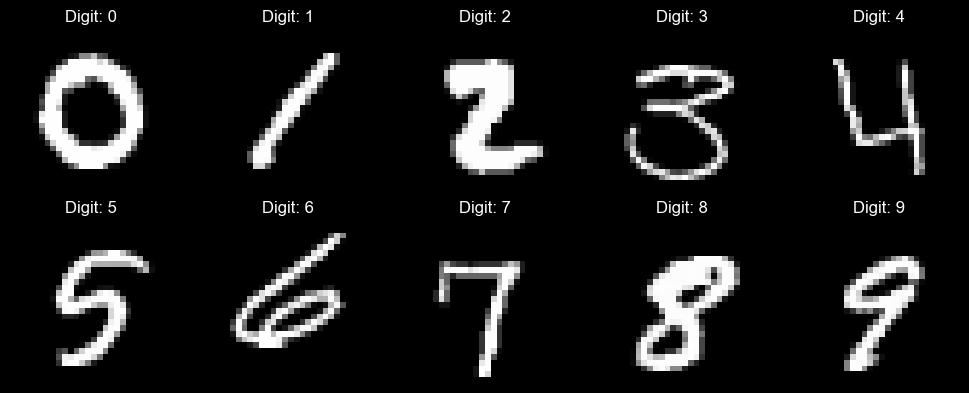

x_train shape: (33600, 784)
x_test shape: (8400, 784)
y_train shape: (33600,)
y_test shape: (8400,)


In [9]:
# pick dataset path (first existing file is used)
base = Path("Dataset")
choices = [base / "mnist_train.csv", base / "mnist_dataset.csv"]
csv_path = None
for p in choices:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("MNIST CSV not found in Dataset folder.")

print("Using file:", csv_path)
x_train, x_test, y_train, y_test = load_and_prepare_mnist(csv_path)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


## 7) Train softmax regression model


Move forward: x and y lengths match.
iter    0 | cost 2.219196
iter  100 | cost 0.602324
iter  200 | cost 0.483234
iter  299 | cost 0.434196


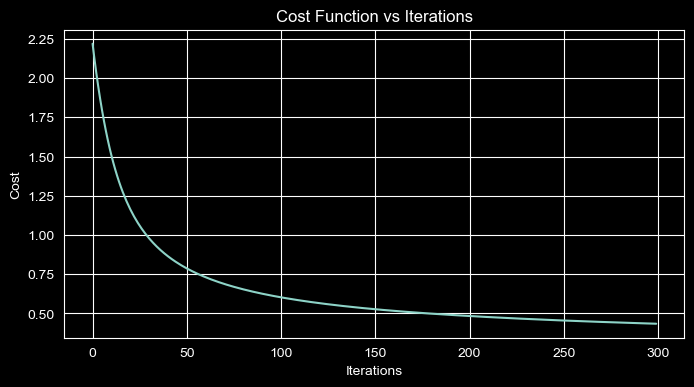

In [10]:
# check shape match
assert len(x_train) == len(y_train), (
    f"Error: x and y have different lengths! x={len(x_train)}, y={len(y_train)}"
)
print("Move forward: x and y lengths match.")

# one-hot encode labels
if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
    enc = OneHotEncoder(sparse_output=False)
else:
    enc = OneHotEncoder(sparse=False)

y_train_hot = enc.fit_transform(y_train.reshape(-1, 1))
y_test_hot = enc.transform(y_test.reshape(-1, 1))

# model setup
np.random.seed(42)
d = x_train.shape[1]
c = y_train_hot.shape[1]
w = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 300  # use 1000 for longer training if needed

w_opt, b_opt, cost_history = gradient_descent_softmax(
    x_train,
    y_train_hot,
    w,
    b,
    alpha,
    n_iter,
    show_cost=True
)

plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


## 8) Evaluate model performance



Confusion Matrix:
[[792   0   4   4   0   6  13   0   6   2]
 [  0 902   3   6   0   9   3   2  11   1]
 [  9   9 718  16  21   3  14  17  22   6]
 [  8   6  32 737   3  35   9  11  20   9]
 [  2   6   7   1 723   1  10   2  10  52]
 [ 13  13   7  38  20 595  16   8  36  13]
 [  6   7  11   1   2  17 776   0   6   1]
 [  6  13  13   4  13   0   1 787   5  38]
 [  5  31   8  25   2  29   7   5 677  24]
 [  6   5   7  12  39   6   1  34   6 722]]
Precision: 0.88
Recall: 0.88
F1-Score: 0.88


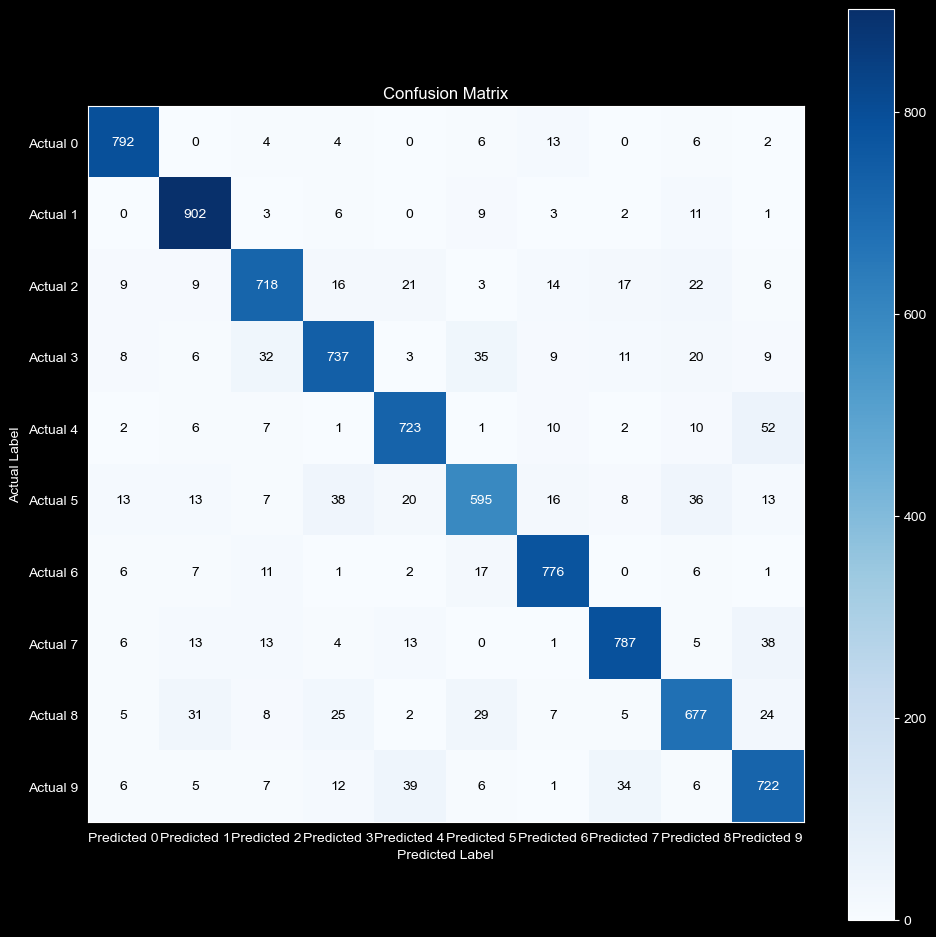

In [11]:
def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return cm, precision, recall, f1


y_pred_test = predict_softmax(x_test, w_opt, b_opt)
y_test_labels = np.argmax(y_test_hot, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(cm, cmap="Blues")
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f"Predicted {i}" for i in range(num_classes)])
ax.set_yticklabels([f"Actual {i}" for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > np.max(cm) / 2 else "black"
        )

ax.grid(False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.colorbar(cax)
plt.show()


## 9) Linear separability and logistic regression exercise


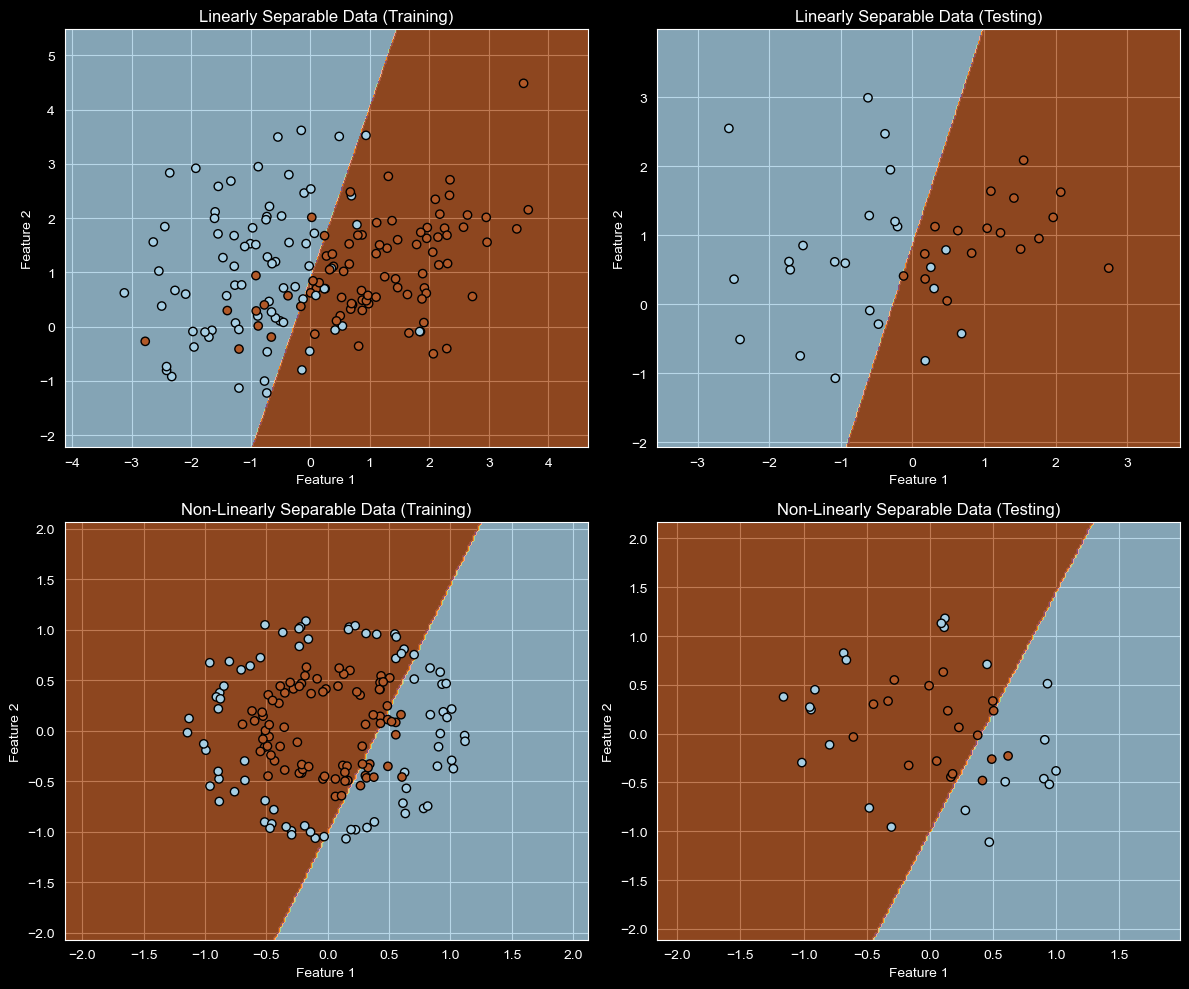

In [12]:
# set seed
np.random.seed(42)

# linearly separable data
x_lin, y_lin = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

x_train_lin, x_test_lin, y_train_lin, y_test_lin = train_test_split(
    x_lin,
    y_lin,
    test_size=0.2,
    random_state=42
)

model_lin = LogisticRegression()
model_lin.fit(x_train_lin, y_train_lin)

# non-linearly separable data
x_non, y_non = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

x_train_non, x_test_non, y_train_non, y_test_non = train_test_split(
    x_non,
    y_non,
    test_size=0.2,
    random_state=42
)

model_non = LogisticRegression()
model_non.fit(x_train_non, y_train_non)


def plot_decision_boundary(ax, model, x, y, title):
    h = 0.02
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    ax.contourf(xx, yy, z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(x[:, 0], x[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(axes[0, 0], model_lin, x_train_lin, y_train_lin, "Linearly Separable Data (Training)")
plot_decision_boundary(axes[0, 1], model_lin, x_test_lin, y_test_lin, "Linearly Separable Data (Testing)")
plot_decision_boundary(axes[1, 0], model_non, x_train_non, y_train_non, "Non-Linearly Separable Data (Training)")
plot_decision_boundary(axes[1, 1], model_non, x_test_non, y_test_non, "Non-Linearly Separable Data (Testing)")

plt.tight_layout()
plt.savefig("decision_boundaries.png")
plt.show()


## 10) Question 2 and Question 3 answers

**Question 2 - Interpretation of the output**

For linearly separable data, logistic regression draws a clean straight boundary and separates classes well.
For non-linearly separable data (circles), logistic regression struggles because one straight boundary is not enough.
So the plot shows a good fit for linear data and a weak fit for circular data.

**Question 3 - Challenges faced**

Main challenges were keeping matrix shapes correct, especially during one-hot encoding and gradient steps.
Another challenge was choosing learning rate and iterations so training is stable and not too slow.
Also, plotting confusion matrix labels clearly needed careful indexing.
